# Assignment #1

##q1: Why is it a good idea to standardize/normalize the predictor variables 2 and 3 and why are predictor variables 4 and 5 probably not very useful by themselves to predict median house values in a block?

read .csv file


In [ ]:
import pandas as pd

df = pd.read_csv('housingUnits.csv')

A. From a pre-processing standpoint of the data, we must think logically before even "touching" the data. First, a housing block can be small or large; it can have (1) house or it can have many; the list goes on. Second, a block can mean many different things. In NYC for example, a block could have just 2 buildings although it could have 500 rooms in it.




B. Standardizing the terminology pertaining to the disussion of blocks for our analysis comes from the need to better understand the relationship our predictors have with our outcome. While experiments may be performed on the data, we need to be able to understand it in a rational, logical way in terms of how it applies to the real world beyond the numbers so we can understand what we are looking at.


C. We now have a better understanding, or intuition, about how to intepret the average layout of houses in relation to their respective block(s) in this data set.

D. This means we will have to take our interpretation of the findings a step further. We don't have the cleanest data but we can rely on a systematic approach to better understanding these data in a manner that is consistent with the natural world. We will use an approach that takes into account the different housing block layouts that make up the vastly different array of neighborhoods in the U.S.





## To meaningfully use predictor variables 2 (number of rooms) and 3 (number of bedrooms), you will need to standardize/normalize them. Using the data, is it better to normalize them by population (4) or number of households (5)?

In [ ]:


## how is it changing why does it makes sense to you (the change that you are observing)


# Normalize by number of households (var5)
df['rooms_per_household'] = df['total_rooms'] / df['households']
df['bedrooms_per_household'] = df['total_bedrooms'] / df['households']


In [ ]:
print(df['rooms_per_household'].min())


print(df['rooms_per_household'].max())


0.8461538461538461
141.9090909090909


In [ ]:
print(df['bedrooms_per_household'].min())



print(df['bedrooms_per_household'].max())



0.35389408099688474
66.0


A. First, I normalized the data. I had to intuit the reasoning behind normalizing by the number of households as opposed to population. This is because the data were not in perfect condition for the task that we are trying to accomplish.  I then normalized by dividing the number of total rooms by the number of households, and then similarly dividing the number of total bedrooms by the number of households.





B. This was to follow the instructions of the question and to minimize the variation that exists within the data, the entire purpose of normalization. I chose to normalize with households because it would give a more accurate representation of the size of the houses per unit of space. On the contrary, normalizing by population may have given more information about the density of the population, which doesn't give as much information about the metric of interest (housing prices).



C. I took the min/max of rooms/bedrooms, normalized per population or household. This allowed me to get a clear picture of the range of the values within each column of interest. From here, I compared which columns (population/household) had the smaller amount of variation and I arrived at my answer. Before normalizing, the values were of a much greater range, meaning they would be more difficult to work with and thus explain later on. After normalizing them, they were in a much more consistent format to take in to account the fact that the blocks are not of consistent size.


D. The findings mean that these data are now more usable after being normalized. Because we are working with data that comes from a diverse set of housing markets, we need to instantiate a common and structured (normalized) categorization of these values listed in variables 2 and 3. This was necessary to avoid any type of misunderstanding given that some of the population(s) may be extremely large with varying block sizes, for example. The normalized values allow us to interpret variables 2 and 3 in a longitudinal way. That is, they can be better applied in the context of the other variables and the outcome variable more broadly.



## 3. Which of the seven variables is most *and* least predictive of housing value, from a simple linear regression perspective? [Hints: a) Make sure to use the standardized/normalized variables from 2. above; b) Make sure to inspect the scatter plots and comment on a potential issue – would the best predictor be even more predictive if not for an unfortunate limitation of the data?]

housing_median_age: R² = 0.012551235533311389


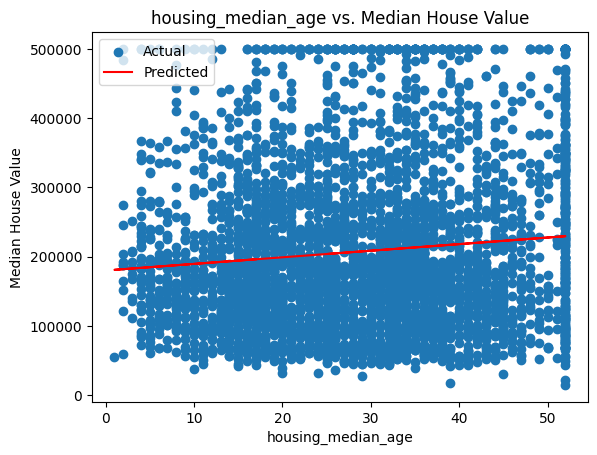

rooms_per_household: R² = 0.01379533753228479


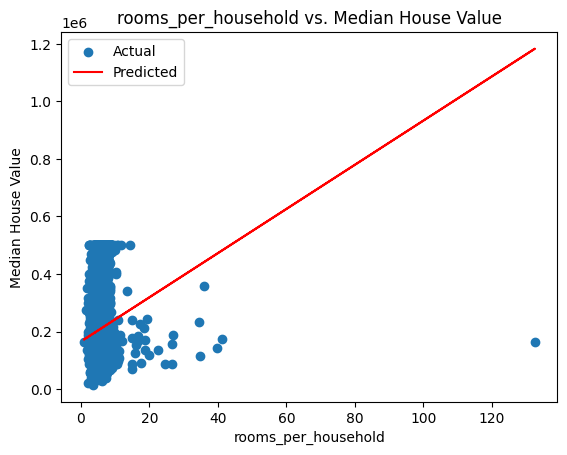

bedrooms_per_household: R² = 0.001600116796480866


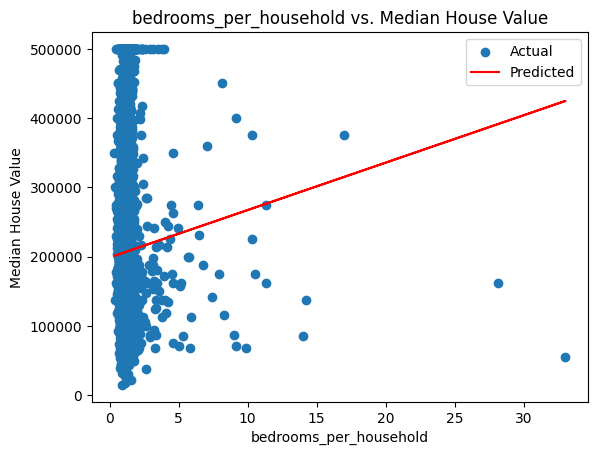

population: R² = 9.303316180364618e-05


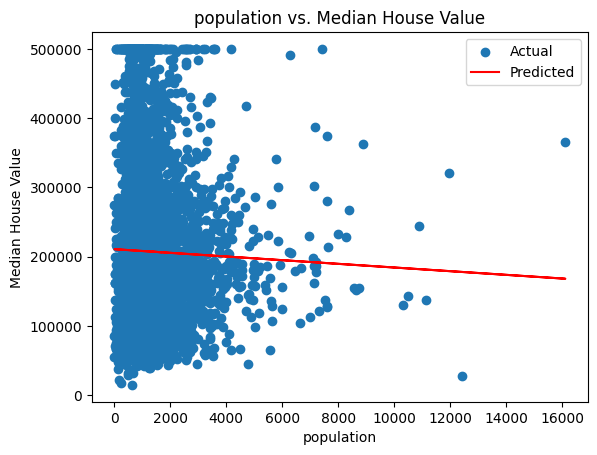

households: R² = 0.005228201940277177


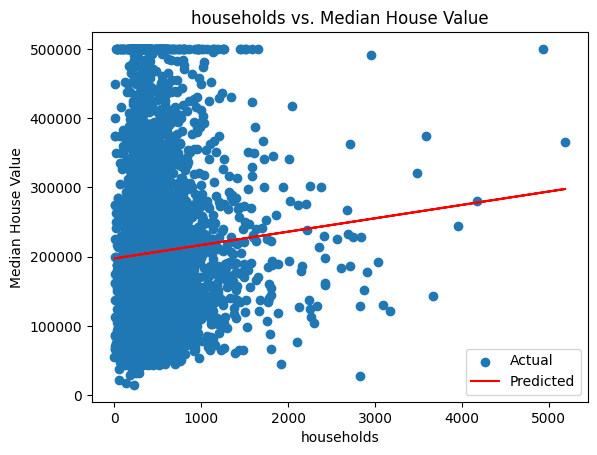

median_income: R² = 0.45885918903846656


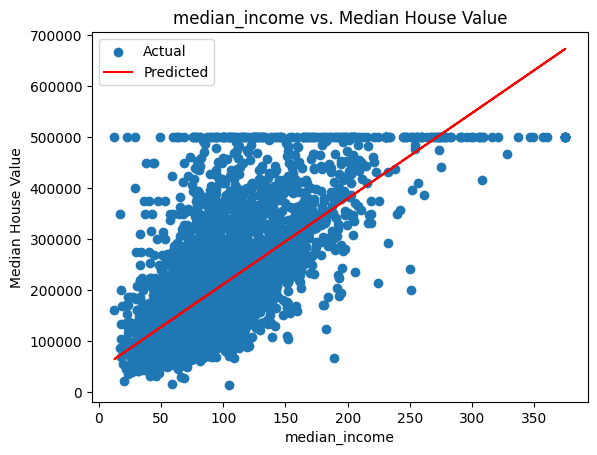

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score


# Predictor variables
predictors = ['housing_median_age', 'rooms_per_household', 'bedrooms_per_household', 'population', 'households', 'median_income', 'ocean_proximity']

# Outcome variable
outcome = 'median_house_value'

# Iterate over predictors to fit and evaluate models
for predictor in predictors:

    if predictor != 'ocean_proximity':
        X = df[[predictor]]
        y = df[outcome]

        # Split data into training and testing sets
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

        # Fit linear regression model
        model = LinearRegression()
        model.fit(X_train, y_train)

        # Predict and calculate R²
        y_pred = model.predict(X_test)
        print(f"{predictor}: R² = {r2_score(y_test, y_pred)}")

        # Plot scatter plot
        plt.scatter(X_test, y_test, label='Actual')
        plt.plot(X_test, y_pred, color='red', label='Predicted')
        plt.title(f"{predictor} vs. Median House Value")
        plt.xlabel(predictor)
        plt.ylabel('Median House Value')
        plt.legend()
        plt.show()


A. Most= median income



Least = population



First, I seperated the variables according to predictor v.s. outcome. Then, I iterated over all the models to fit them with my data. I split the data into training and test sets, and proceeded to predict and calculate my R^2 values.






B. This was done to analyze, compare, and illustrate which predictor had the strongest relationship with  house value. We would want to compare each predictor individually to determine this relationship for each predictor. I fit the training size to .80% because this is a good size to avoid over or underfitting. I then plotted the scatter plots to illutrate the accuracy of the models.




C. I got relatively low R^2 values for most of my features. This means that the regression line did not accurately approximate most of the features. However, I found that the highest R^2 value was median income and the lowest was population.




D. This means that areas that have high household income tend to favor well in terms of their properties value. This could mean that these people are putting more money into their properties. As for the low R^2 value for population, it could mean that the amount of people that reside on a block bears no correlation or importance to the property value of a house. In other words, densely populated areas could have the same priced homes as less populated areas.


D(Cont). The best predictor (income) would have been better if not for the house cutoff value at 500,000. The R^2 value would have likely gone up as the regression line would have more values to fit.


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import pandas as pd

# Assuming df is your DataFrame

# Prepare predictors X and outcome y
X = df[['housing_median_age', 'rooms_per_household', 'bedrooms_per_household', 'population', 'households', 'median_income']] # Add 'ocean_proximity' if encoded
y = df['median_house_value']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit multiple regression model
model_multiple = LinearRegression()
model_multiple.fit(X_train, y_train)

# Predict and calculate R² for multiple regression
y_pred_multiple = model_multiple.predict(X_test)
r2_multiple = r2_score(y_test, y_pred_multiple)
print(f"Multiple Regression R²: {r2_multiple}")

r2_best_single = df['median_income']

# Compare
print(f"Best Single Predictor R²: {0.45885918903846656}")  # Replace with actual R² value obtained earlier

# Assess improvement
if r2_multiple > 0.45885918903846656:
    print("Multiple regression model performs better.")
else:
    print("Best single predictor model performs comparably or better.")


Multiple Regression R²: 0.5434329435225611
Best Single Predictor R²: 0.45885918903846656
Multiple regression model performs better.


A. I loaded all of the predictors into an array named x, with the variable of interest into an array named y. I then split the training and test data into .80% again to preserve the fitting of the model. I fit a multiple linear regression model using the imported packages and then predicted and calculated the R^2 value. I took the "best" R^2 value I calculated from the single linear regression problem above and I compared it to the value I achieved in the multiple regression model.

B. This was done to compare the accuracy of the model(s). By taking the best predictor from the single linear regression, we can understand how well it compares against all of the predictors as a whole in the multiple regression model. I was then able to access the improvement of the multiple regression model on a percentage basis and compare it with that of the single linear regression model.


C. I found that the multiple regression model performed better (R²: 0.5434329435225611) than the single linear regression model predictor 'median income' (R²: 0.45885918903846656) by roughly %9.


D. When performing multiple linear regression, all of the features are used. This makes sense in the case of my answer, which shows that the multiple regression model explains the housing values more efficently than income alone. Although the percent is better by 9%, we know that income definetly plays a large part in the housing value, given that it has a relatively large r^2 value of 0.45885918903846656 as is, which is large for a single predictor. All in all, with the combination of the other predictors, we can see that they play a role (although small) in explaining the greater picture in housing prices

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
import pandas as pd

X = df[['total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']]
X = add_constant(X)  # Add an intercept to the model

# Calculate VIF
vif = pd.DataFrame()
vif["VIF Factor"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif["features"] = X.columns

print(vif)


     VIF Factor        features
0  4.980169e+04           const
1  1.812332e+06     total_rooms
2  1.812196e+06  total_bedrooms
3  5.826275e+00      population
4  1.089519e+01      households
5  1.296861e+00   median_income


A. I calculated the variance inflation factor for each predictor.  I stored the results including the VIF values and their feature names in a new data frame. This was done to better understand if predictor variables 2 and 3 were collectively influencing how the outcome variable is being produced, which is an issue for our experiment.   



B. This is to determine how much of the variance of a regression coefficient increases if the predictors are correlated. This was the most straightforward way for me to approach analyzing the collinearity. More specifically, the VIF was used because it is a superior way to indicate the degree to which collinearity is present.


C. I found that variables 2 and 3 had a substantial relationship. Because of this issue regarding collinearity, we understand that the two variables share an excessive amount of data. This increases the difficulty in accurately discerning the effect that each feature is having on the outcome variable, housing value. Additionallty, there is a moderately high value for population and household, showing that more households might mean there is a higher population. I would suggest this demonstrates this is of equal concern to the colinearity of variables 2 and 3.

D. The findings mean that there is a high degree of colinearity between total_rooms and total_bedrooms, showing they have a combined influence on the housing prices. They could possibly be misleading our interpretation of our results (not the results themselves) because we have to be more precise in how we look at how the number of rooms in general may influence the size of the house, the type of the house, value etc. Similarly, for variables 4 and 5, the problem of collinearity must be considered when interpreting the housing price findings because they could reveal information about the location that is unique to a particular market, for example.


# Extra Credit

Does any of the variables (predictor or outcome) follow a distribution that can reasonably
be described as a normal distribution?


<ipython-input-46-d86f1affa8f2>:17: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[column].dropna(), kde=True, bins=30)  # Adjust bins as necessary
<ipython-input-46-d86f1affa8f2>:17: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[column].dropna(), kde=True, bins=30)  # Adjust bins as necess

ValueError: num must be an integer with 1 <= num <= 9, not 10

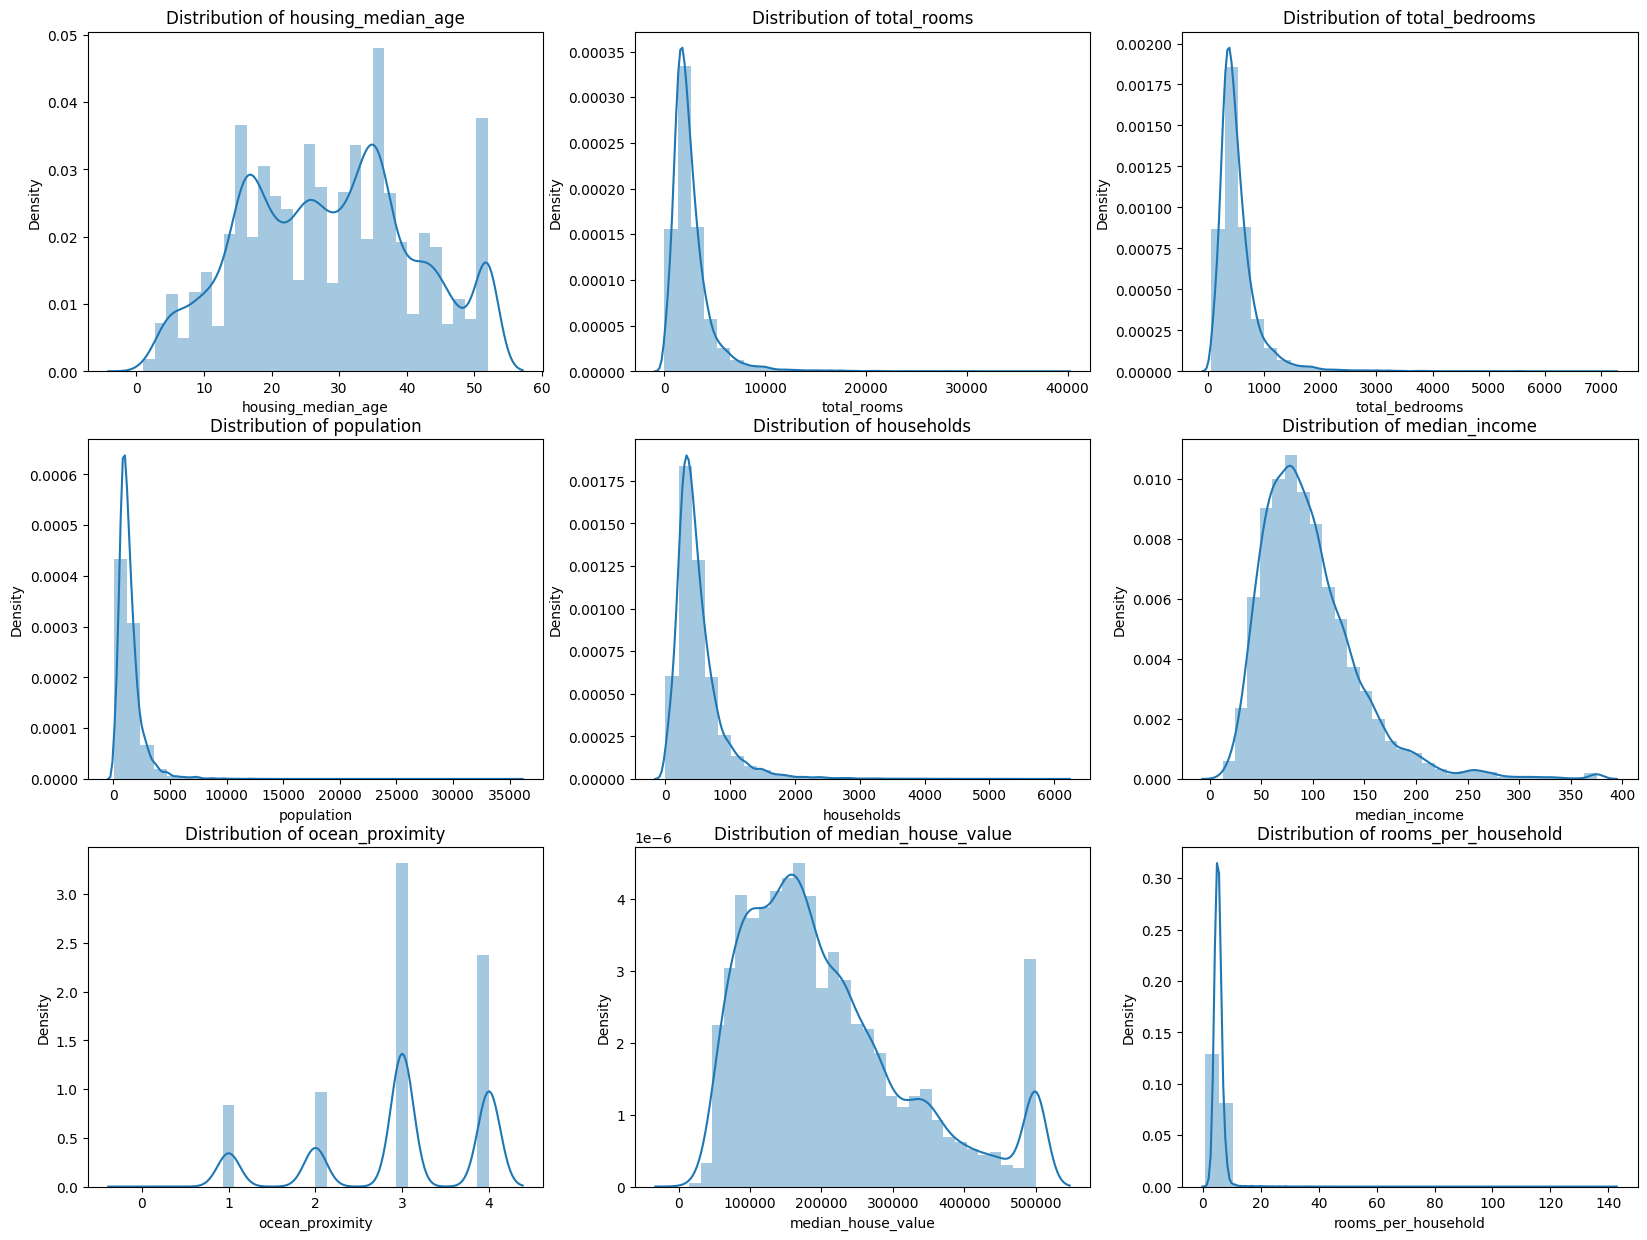

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming df is your DataFrame and it's already loaded
# Load the dataset if not already loaded
# df = pd.read_csv('/path/to/your/dataset.csv')

# List of all columns for which to plot distributions
columns = df.columns

# Set up the matplotlib figure
plt.figure(figsize=(20, 15))

for i, column in enumerate(columns, 1):
    plt.subplot(3, 3, i)  # Adjust the grid size (3, 3) based on the number of your variables
    sns.distplot(df[column].dropna(), kde=True, bins=30)  # Adjust bins as necessary
    plt.title(f'Distribution of {column}')

plt.tight_layout()
plt.show()


As pictured by the plots above, the only feature that evenly remotely follows a normal distribution is median income, which is still far from a bell shaped curve. All of the distributions have some form of skewedness. Thus, none of them are a normal distribution.

b) Examine the distribution of the outcome variable. Are there any characteristics of this
distribution that might limit the validity of the conclusions when answering the questions
above? If so, please comment on this characteristic.

Median house value has a couple of characteristics that may limit its validity. First, it has a peak at the lower end showing a large percentage of lower median house values. The long right tail or "skew" may indicate there is a smaller number of blocks with much higher median house values. Lastly, there are sharp peaks, demonstrating the limit on the value of the homes ending at around 500,000.